# Phase 2: Non-Linear Modeling, Autoregressive Features, and Gradient Boosting

**Objective:** Build on the Phase 1 baseline by training more flexible machine-learning models on the same time-aware feature pipeline. This updated notebook adds:
- `lag_pop_change_1`
- `lag_pop_change_2`
- `income_growth`
- a **HistGradientBoosting model** in addition to Random Forest

The goal is to test whether autoregressive signals and boosting-based nonlinear modeling can improve held-out predictive performance.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
from math import radians, cos, sin, asin, sqrt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.inspection import permutation_importance

def haversine(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    dlon, dlat = lon2 - lon1, lat2 - lat1
    a = sin(dlat / 2) ** 2 + cos(lat1) * cos(lat1) * sin(dlon / 2) ** 2
    return 2 * asin(sqrt(a)) * 6371


## 1. Data Ingestion & Spatial Initialization
We begin by loading the consolidated historical profile for Puerto Rico (2010-2024). 

Because disaster impacts are highly localized, we map each of the 78 municipalities to its exact geographic centroid (Latitude/Longitude). This spatial initialization is crucial for the vectorized distance functions that calculate how close the eye of a hurricane or the epicenter of an earthquake was to a specific town.

In [2]:
# 1. Load Data
df = pd.read_csv('../data/puerto_rico_master_profile.csv')
df['municipio'] = df['municipio'].str.replace(' Municipio', '', case=False).str.strip()
df = df.sort_values(by=['municipio', 'year']).reset_index(drop=True)

# 2. Add Coordinates
municipio_coords = {'Adjuntas': (18.1627, -66.7222), 'Aguada': (18.3605, -67.1882), 'Aguadilla': (18.4275, -67.1541), 'Aguas Buenas': (18.2572, -66.1031), 'Aibonito': (18.1408, -66.2663), 'Añasco': (18.2827, -67.1399), 'Arecibo': (18.4724, -66.7157), 'Arroyo': (17.9658, -66.0614), 'Barceloneta': (18.4505, -66.5385), 'Barranquitas': (18.1861, -66.3061), 'Bayamón': (18.3808, -66.1557), 'Cabo Rojo': (18.0866, -67.1457), 'Caguas': (18.2325, -66.0391), 'Camuy': (18.4838, -66.8450), 'Canóvanas': (18.3791, -65.9011), 'Carolina': (18.3808, -65.9574), 'Cataño': (18.4388, -66.1182), 'Cayey': (18.1119, -66.1663), 'Ceiba': (18.2633, -65.6474), 'Ciales': (18.3361, -66.4688), 'Cidra': (18.1758, -66.1617), 'Coamo': (18.0855, -66.3579), 'Comerío': (18.2183, -66.2257), 'Corozal': (18.3411, -66.3161), 'Culebra': (18.3030, -65.3010), 'Dorado': (18.4588, -66.2677), 'Fajardo': (18.3258, -65.6524), 'Florida': (18.3625, -66.5614), 'Guánica': (17.9716, -66.9080), 'Guayama': (17.9741, -66.1100), 'Guayanilla': (18.0130, -66.7919), 'Guaynabo': (18.3580, -66.1111), 'Gurabo': (18.2544, -65.9728), 'Hatillo': (18.4863, -66.8250), 'Hormigueros': (18.1397, -67.1274), 'Humacao': (18.1497, -65.8274), 'Isabela': (18.5011, -67.0247), 'Jayuya': (18.2186, -66.5916), 'Juana Díaz': (18.0525, -66.5064), 'Juncos': (18.2275, -65.9211), 'Lajas': (18.0497, -67.0594), 'Lares': (18.2947, -66.8771), 'Las Marías': (18.2514, -66.9922), 'Las Piedras': (18.1827, -65.8661), 'Loíza': (18.4330, -65.8797), 'Luquillo': (18.3725, -65.7166), 'Manatí': (18.4274, -66.4922), 'Maricao': (18.1808, -66.9799), 'Maunabo': (18.0072, -65.8994), 'Mayagüez': (18.2011, -67.1397), 'Moca': (18.3947, -67.1131), 'Morovis': (18.3258, -66.4053), 'Naguabo': (18.2119, -65.7350), 'Naranjito': (18.3008, -66.2447), 'Orocovis': (18.2269, -66.4411), 'Patillas': (18.0066, -66.0161), 'Peñuelas': (18.0622, -66.7219), 'Ponce': (18.0111, -66.6141), 'Quebradillas': (18.4738, -66.9385), 'Rincón': (18.3403, -67.2500), 'Río Grande': (18.3794, -65.8311), 'Sabana Grande': (18.0777, -66.9605), 'Salinas': (17.9775, -66.2974), 'San Germán': (18.0816, -67.0400), 'San Juan': (18.4655, -66.1057), 'San Lorenzo': (18.1894, -65.9611), 'San Sebastián': (18.3372, -66.9905), 'Santa Isabel': (17.9666, -66.4050), 'Toa Alta': (18.3883, -66.2485), 'Toa Baja': (18.4438, -66.2591), 'Trujillo Alto': (18.3547, -66.0072), 'Utuado': (18.2655, -66.7005), 'Vega Alta': (18.4119, -66.3314), 'Vega Baja': (18.4438, -66.3874), 'Vieques': (18.1261, -65.4400), 'Villalba': (18.1275, -66.4925), 'Yabucoa': (18.0505, -65.8794), 'Yauco': (18.0350, -66.8499)}
df['lat'] = df['municipio'].map(lambda x: municipio_coords.get(x, (None, None))[0])
df['lon'] = df['municipio'].map(lambda x: municipio_coords.get(x, (None, None))[1])

# 3. Process Shocks
hurricane_tracks = pd.read_csv('../data/natural_disasters/caribbean_hurricane_tracks_2010_2025.csv')
with open('../data/natural_disasters/puerto_rico_earthquakes.json') as f:
    eq_data = pd.DataFrame(json.load(f))
eq_data['year'] = pd.to_datetime(eq_data['date']).dt.year

def get_distances_vectorized(target_lat, target_lon, lats, lons):
    target_lat, target_lon = np.radians(target_lat), np.radians(target_lon)
    lats, lons = np.radians(lats), np.radians(lons)
    return 2 * np.arcsin(np.sqrt(np.sin((lats - target_lat)/2)**2 + np.cos(target_lat) * np.cos(lats) * np.sin((lons - target_lon)/2)**2)) * 6371

def get_shocks(row):
    if pd.isna(row['lat']): return 0, 0
    # Hurricane
    h_year = hurricane_tracks[hurricane_tracks['Year'] == row['year']]
    h_max = h_year.iloc[get_distances_vectorized(row['lat'], row['lon'], h_year['Lat'].values, h_year['Lon'].values) <= 100]['Wind_Knots'].max() if not h_year.empty else 0
    # Seismic
    s_year = eq_data[(eq_data['year'] == row['year']) & (eq_data['mag'] >= 4.0)]
    s_max = s_year.iloc[get_distances_vectorized(row['lat'], row['lon'], s_year['latitude'].values, s_year['longitude'].values) <= 50]['mag'].max() if not s_year.empty else 0
    return h_max if not pd.isna(h_max) else 0, s_max if not pd.isna(s_max) else 0

df[['max_wind_knots', 'max_seismic_mag']] = df.apply(lambda r: pd.Series(get_shocks(r)), axis=1)

## 2. Non-Leaked Feature Engineering Pipeline

This phase preserves the Phase 1 modeling logic while upgrading the learner. The feature-engineering pipeline now includes:

- the **SVI-15 vulnerability index** from PCA
- lagged crime features
- two **lagged population-change variables**
- **income growth**
- time-aware train/test splitting
- train-only PCA fitting to prevent leakage

These additions are intended to capture the strong persistence and momentum that often characterize municipal population change.


In [3]:
# --- STEP 1: INTEGRATE CRIME SHOCKS ---
def load_crime_data_fixed(file_path):
    xl = pd.ExcelFile(file_path)
    all_years = []
    for sheet_name in xl.sheet_names:
        if not sheet_name.isdigit():
            continue
        df_year = xl.parse(sheet_name)
        df_year.columns = [str(c).strip().lower() for c in df_year.columns]

        mun_cols = [c for c in df_year.columns if 'mun' in c]
        if mun_cols:
            df_year = df_year.rename(columns={mun_cols[0]: 'municipio'})

        df_year = df_year.loc[:, ~df_year.columns.duplicated()]
        df_year = df_year.rename(columns={'total ': 'total'})

        numeric_cols = ['murder', 'robbery', 'burglary', 'larceny / theft', 'total']
        for col in numeric_cols:
            if col in df_year.columns:
                df_year[col] = (
                    df_year[col]
                    .astype(str)
                    .str.replace('.', '', regex=False)
                    .str.replace(',', '', regex=False)
                )
                df_year[col] = pd.to_numeric(df_year[col], errors='coerce').fillna(0).astype(int)

        df_year['year'] = int(sheet_name)
        keep_cols = ['municipio', 'year'] + [c for c in numeric_cols if c in df_year.columns]
        all_years.append(df_year[keep_cols])

    return pd.concat(all_years, ignore_index=True)

crime_path = '../data/crime/PR_Crime_Summary_2010_2025.xlsx'
crime_df = load_crime_data_fixed(crime_path)

df['mun_key'] = df['municipio'].astype(str).str.upper().str.strip().str.replace(' MUNICIPIO', '', regex=False)
crime_df['mun_key'] = crime_df['municipio'].astype(str).str.upper().str.strip()

df = df.merge(crime_df.drop(columns=['municipio']), on=['mun_key', 'year'], how='left')
df = df.fillna(0)
df = df.drop(columns=['mun_key'])

df['murder_rate'] = (df['murder'] / df['total_population']) * 1000
df['robbery_rate'] = (df['robbery'] / df['total_population']) * 1000
df['burglary_rate'] = (df['burglary'] / df['total_population']) * 1000

df = df.sort_values(['municipio', 'year']).copy()
df['year'] = pd.to_numeric(df['year'], errors='coerce')
df['target_pop_change'] = df.groupby('municipio')['total_population'].pct_change() * 100

df['lag_violent_crime_rate'] = (
    df.groupby('municipio')['murder_rate'].shift(1) +
    df.groupby('municipio')['robbery_rate'].shift(1)
)
df['lag_property_crime_rate'] = df.groupby('municipio')['burglary_rate'].shift(1)

df['lag_pop_change_1'] = df.groupby('municipio')['target_pop_change'].shift(1)
df['lag_pop_change_2'] = df.groupby('municipio')['target_pop_change'].shift(2)
df['income_growth'] = df.groupby('municipio')['median_income_real'].pct_change() * 100

svi_cols = [
    'poverty_rate_pct',
    'unemployment_rate_pct',
    'per_capita_income',
    'no_hs_diploma_pct',
    'under_18_pct',
    'over_65_pct',
    'disability_pct',
    'single_parent_pct',
    'minority_pct',
    'limited_english_pct',
    'multi_unit_housing_pct',
    'mobile_homes_pct',
    'crowding_pct',
    'no_vehicle_pct',
    'pct_group_quarters'
]

for col in svi_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['per_capita_income_inv'] = -df['per_capita_income']

svi_pca_cols = [
    'poverty_rate_pct',
    'unemployment_rate_pct',
    'per_capita_income_inv',
    'no_hs_diploma_pct',
    'under_18_pct',
    'over_65_pct',
    'disability_pct',
    'single_parent_pct',
    'minority_pct',
    'limited_english_pct',
    'multi_unit_housing_pct',
    'mobile_homes_pct',
    'crowding_pct',
    'no_vehicle_pct',
    'pct_group_quarters'
]

other_cols = [
    'median_income_real',
    'max_wind_knots',
    'max_seismic_mag',
    'lag_pop_change_1',
    'lag_pop_change_2',
    'income_growth'
]

crime_features = ['lag_violent_crime_rate', 'lag_property_crime_rate']

for col in other_cols + crime_features:
    df[col] = pd.to_numeric(df[col], errors='coerce')

required_cols = ['municipio', 'year', 'target_pop_change'] + svi_pca_cols + other_cols + crime_features

df = df.replace([np.inf, -np.inf], np.nan)
df_clean = df.dropna(subset=required_cols).copy()

train_end_year = 2020
test_start_year = 2021
train_mask = df_clean['year'] <= train_end_year
test_mask = df_clean['year'] >= test_start_year

if not train_mask.any() or not test_mask.any():
    raise ValueError("Time-based split produced an empty train or test set. Check the year range in df_clean.")

df_clean['split'] = np.where(train_mask, 'train', np.where(test_mask, 'test', 'unused'))
df_model = df_clean[df_clean['split'].isin(['train', 'test'])].copy()

train_df = df_model[df_model['split'] == 'train'].copy()
test_df = df_model[df_model['split'] == 'test'].copy()

scaler_svi = StandardScaler()
pca_svi = PCA(n_components=1, random_state=42)

train_svi_scaled = scaler_svi.fit_transform(train_df[svi_pca_cols])
test_svi_scaled = scaler_svi.transform(test_df[svi_pca_cols])

train_df['vulnerability_index'] = pca_svi.fit_transform(train_svi_scaled).ravel()
test_df['vulnerability_index'] = pca_svi.transform(test_svi_scaled).ravel()

loading_series = pd.Series(pca_svi.components_[0], index=svi_pca_cols)
if loading_series[['poverty_rate_pct', 'unemployment_rate_pct', 'no_vehicle_pct']].mean() < 0:
    train_df['vulnerability_index'] = -train_df['vulnerability_index']
    test_df['vulnerability_index'] = -test_df['vulnerability_index']
    loading_series = -loading_series

df_model = pd.concat([train_df, test_df], axis=0).sort_index()

features = [
    'vulnerability_index',
    'median_income_real',
    'max_wind_knots',
    'max_seismic_mag',
    'lag_violent_crime_rate',
    'lag_property_crime_rate',
    'lag_pop_change_1',
    'lag_pop_change_2',
    'income_growth'
]

X_train = train_df[features].copy()
X_test = test_df[features].copy()
y_train = train_df['target_pop_change'].copy()
y_test = test_df['target_pop_change'].copy()

print("--- Phase 2 data preparation complete ---")
print(f"Training years: <= {train_end_year}")
print(f"Testing years: >= {test_start_year}")
print(f"Train rows: {len(train_df)}")
print(f"Test rows: {len(test_df)}")
print(f"Explained variance of PCA component: {pca_svi.explained_variance_ratio_[0]:.4f}")
print("\nFinal Phase 2 features:")
for f in features:
    print(f" - {f}")


--- Phase 2 data preparation complete ---
Training years: <= 2020
Testing years: >= 2021
Train rows: 624
Test rows: 312
Explained variance of PCA component: 0.2363

Final Phase 2 features:
 - vulnerability_index
 - median_income_real
 - max_wind_knots
 - max_seismic_mag
 - lag_violent_crime_rate
 - lag_property_crime_rate
 - lag_pop_change_1
 - lag_pop_change_2
 - income_growth


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: overflow encountered in matmul
  X_

### SVI PCA Input Diagnostics

Before scaling and PCA, inspect the SVI input columns for extreme or malformed values. This helps identify percentage variables outside plausible ranges or unusually large finite values that could destabilize PCA.


In [4]:

# Inspect SVI PCA inputs before scaling/PCA
print("--- SVI PCA Input Diagnostics ---")

svi_diag = df_clean[svi_pca_cols].describe(
    percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]
).T
display(svi_diag)

max_abs_svi = df_clean[svi_pca_cols].abs().max().sort_values(ascending=False)
print("\nMaximum absolute value by SVI PCA column:")
display(max_abs_svi.to_frame(name='max_abs_value'))

# Flag columns that may warrant closer review
pct_like_cols = [c for c in svi_pca_cols if c != 'per_capita_income_inv']
flagged_pct = max_abs_svi.loc[pct_like_cols][max_abs_svi.loc[pct_like_cols] > 100]
if not flagged_pct.empty:
    print("\nPotentially suspicious percentage-style columns (>100 observed):")
    display(flagged_pct.to_frame(name='max_abs_value'))
else:
    print("\nNo percentage-style SVI columns exceeded 100 in absolute value.")

if 'per_capita_income_inv' in svi_pca_cols:
    print("\nPer capita income (inverted) summary:")
    display(df_clean[['per_capita_income', 'per_capita_income_inv']].describe().T)


--- SVI PCA Input Diagnostics ---


,count,mean,std,min,1%,5%,50%,95%,99%,max
poverty_rate_pct,936.0,47.266400,8.450182,20.84,26.0515,30.6775,48.200,60.2850,64.3040,67.07
unemployment_rate_pct,936.0,16.484615,7.391615,0.00,2.8700,6.0000,15.900,29.5250,34.1000,40.90
per_capita_income_inv,936.0,-11451.929487,3703.248317,-34713.00,-24761.0000,-18126.5000,-10609.000,-7191.5000,-6658.2500,-5663.00
no_hs_diploma_pct,936.0,27.654968,7.069779,11.12,14.0080,16.8375,27.330,40.1025,48.8870,53.70
under_18_pct,936.0,20.316132,2.861418,13.54,14.9605,15.8750,20.235,25.0625,26.3530,28.04
over_65_pct,936.0,19.653729,3.838632,10.36,12.5315,13.8475,19.430,26.2125,29.3390,33.26
disability_pct,936.0,21.205321,6.298447,6.56,7.4305,9.1500,21.710,31.2850,34.8665,39.39
single_parent_pct,936.0,13.476100,2.752179,6.51,7.8275,9.0550,13.440,18.1075,19.7420,21.86
minority_pct,936.0,99.181335,1.182947,90.05,93.5840,96.8100,99.550,99.9600,100.0000,100.00
limited_english_pct,936.0,11.896058,12.899173,0.00,0.0000,0.0000,3.400,33.3250,38.4710,46.80



Maximum absolute value by SVI PCA column:


,max_abs_value
per_capita_income_inv,34713.00
minority_pct,100.00
poverty_rate_pct,67.07
no_hs_diploma_pct,53.70
limited_english_pct,46.80
unemployment_rate_pct,40.90
disability_pct,39.39
crowding_pct,37.55
over_65_pct,33.26
no_vehicle_pct,32.92



No percentage-style SVI columns exceeded 100 in absolute value.

Per capita income (inverted) summary:


,count,mean,std,min,25%,50%,75%,max
per_capita_income,936.0,11451.929487,3703.248317,5663.0,8979.50,10609.0,13065.75,34713.0
per_capita_income_inv,936.0,-11451.929487,3703.248317,-34713.0,-13065.75,-10609.0,-8979.50,-5663.0


## 3. Non-Linear Modeling: Random Forest and HistGradientBoosting

This phase now compares two flexible nonlinear learners:

- **Random Forest** for robust, low-tuning ensemble modeling
- **HistGradientBoosting** for gradient-boosted decision trees built into scikit-learn, which often perform well on structured tabular data

Because population change may depend on nonlinear interactions and recent momentum, both models are trained and evaluated on the same held-out future period.


In [5]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

y_pred_rf_default = rf_model.predict(X_test)

rf_default_r2 = r2_score(y_test, y_pred_rf_default)
rf_default_mae = mean_absolute_error(y_test, y_pred_rf_default)
rf_default_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf_default))

default_results = pd.DataFrame({
    'Model': ['Random Forest (default)'],
    'R2': [rf_default_r2],
    'MAE': [rf_default_mae],
    'RMSE': [rf_default_rmse]
})

print("--- Default Random Forest Performance ---")
display(default_results)


--- Default Random Forest Performance ---


,Model,R2,MAE,RMSE
0,Random Forest (default),-0.253577,1.761633,3.165211


In [6]:
train_cv_df = train_df[['year'] + features + ['target_pop_change']].sort_values('year').reset_index(drop=True)
X_train_cv = train_cv_df[features]
y_train_cv = train_cv_df['target_pop_change']

n_splits = min(5, max(2, train_cv_df['year'].nunique() - 1))
tscv = TimeSeriesSplit(n_splits=n_splits)

rf_param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'bootstrap': [True, False]
}

rf_grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=rf_param_grid,
    cv=tscv,
    n_jobs=-1,
    verbose=1,
    scoring='r2'
)

print("Starting time-aware Random Forest hyperparameter optimization...")
rf_grid_search.fit(X_train_cv, y_train_cv)

best_rf = rf_grid_search.best_estimator_
y_pred_rf_tuned = best_rf.predict(X_test)

rf_tuned_r2 = r2_score(y_test, y_pred_rf_tuned)
rf_tuned_mae = mean_absolute_error(y_test, y_pred_rf_tuned)
rf_tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf_tuned))

lgbm_default = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05, max_depth=6, random_state=42)
lgbm_default.fit(X_train, y_train)

y_pred_lgbm_default = lgbm_default.predict(X_test)
lgbm_default_r2 = r2_score(y_test, y_pred_lgbm_default)
lgbm_default_mae = mean_absolute_error(y_test, y_pred_lgbm_default)
lgbm_default_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lgbm_default))

lgbm_param_grid = {
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [3, 5, 7, None],
    'min_samples_leaf': [10, 20, 30],
    'max_leaf_nodes': [15, 31, 63],
    'l2_regularization': [0.0, 0.1, 1.0]
}

lgbm_grid_search = GridSearchCV(
    estimator=HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05, max_depth=6, random_state=42),
    param_grid=lgbm_param_grid,
    cv=tscv,
    n_jobs=-1,
    verbose=1,
    scoring='r2'
)

print("\nStarting time-aware HistGradientBoosting hyperparameter optimization...")
lgbm_grid_search.fit(X_train_cv, y_train_cv)

best_lgbm = lgbm_grid_search.best_estimator_
y_pred_lgbm_tuned = best_lgbm.predict(X_test)

lgbm_tuned_r2 = r2_score(y_test, y_pred_lgbm_tuned)
lgbm_tuned_mae = mean_absolute_error(y_test, y_pred_lgbm_tuned)
lgbm_tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lgbm_tuned))

phase1_baseline_r2 = -0.3814

comparison_df = pd.DataFrame({
    'Model': [
        'Phase 1 OLS baseline',
        'Random Forest (default)',
        'Random Forest (tuned)',
        'HistGradientBoosting (default)',
        'HistGradientBoosting (tuned)'
    ],
    'R2': [
        phase1_baseline_r2,
        rf_default_r2,
        rf_tuned_r2,
        lgbm_default_r2,
        lgbm_tuned_r2
    ],
    'MAE': [
        np.nan,
        rf_default_mae,
        rf_tuned_mae,
        lgbm_default_mae,
        lgbm_tuned_mae
    ],
    'RMSE': [
        np.nan,
        rf_default_rmse,
        rf_tuned_rmse,
        lgbm_default_rmse,
        lgbm_tuned_rmse
    ]
})

candidate_models = {
    'Random Forest (tuned)': (best_rf, y_pred_rf_tuned, rf_tuned_r2),
    'HistGradientBoosting (tuned)': (best_lgbm, y_pred_lgbm_tuned, lgbm_tuned_r2)
}
best_model_name, (best_model, y_best_pred, best_model_r2) = max(
    candidate_models.items(),
    key=lambda item: item[1][2]
)

print("\n--- Tuned Model Comparison ---")
print(f"Best RF Parameters: {rf_grid_search.best_params_}")
print(f"Best LightGBM Parameters: {lgbm_grid_search.best_params_}")
display(comparison_df)

r2_gain = best_model_r2 - phase1_baseline_r2
print(f"Selected best model for downstream use: {best_model_name}")
print(f"Absolute R2 improvement over Phase 1 baseline: {r2_gain:.4f}")


Starting time-aware Random Forest hyperparameter optimization...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Starting time-aware HistGradientBoosting hyperparameter optimization...
Fitting 5 folds for each of 324 candidates, totalling 1620 fits

--- Tuned Model Comparison ---
Best RF Parameters: {'bootstrap': True, 'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 400}
Best LightGBM Parameters: {'l2_regularization': 1.0, 'learning_rate': 0.03, 'max_depth': None, 'max_leaf_nodes': 15, 'min_samples_leaf': 30}


,Model,R2,MAE,RMSE
0,Phase 1 OLS baseline,-0.381400,NaN,NaN
1,Random Forest (default),-0.253577,1.761633,3.165211
2,Random Forest (tuned),-0.245867,1.776656,3.155463
3,HistGradientBoosting (default),-0.379500,1.891645,3.320383
4,HistGradientBoosting (tuned),-0.347288,1.846571,3.281387


Selected best model for downstream use: Random Forest (tuned)
Absolute R2 improvement over Phase 1 baseline: 0.1355


## 4. Permutation Importance: Which Variables Matter Most?

Rather than relying only on built-in importance measures, this section applies **permutation importance** to the **best-performing tuned model** selected above. This makes the interpretation step consistent with the strongest Phase 2 learner rather than assuming Random Forest is always best.


,Feature,Importance_Mean,Importance_SD
3,max_seismic_mag,0.000843,0.000774
4,lag_violent_crime_rate,0.000599,0.001626
5,lag_property_crime_rate,0.000453,0.000870
2,max_wind_knots,-0.000077,0.000625
8,income_growth,-0.000179,0.001094
1,median_income_real,-0.001320,0.000759
0,vulnerability_index,-0.001631,0.001198
7,lag_pop_change_2,-0.041372,0.019554
6,lag_pop_change_1,-0.053599,0.017549


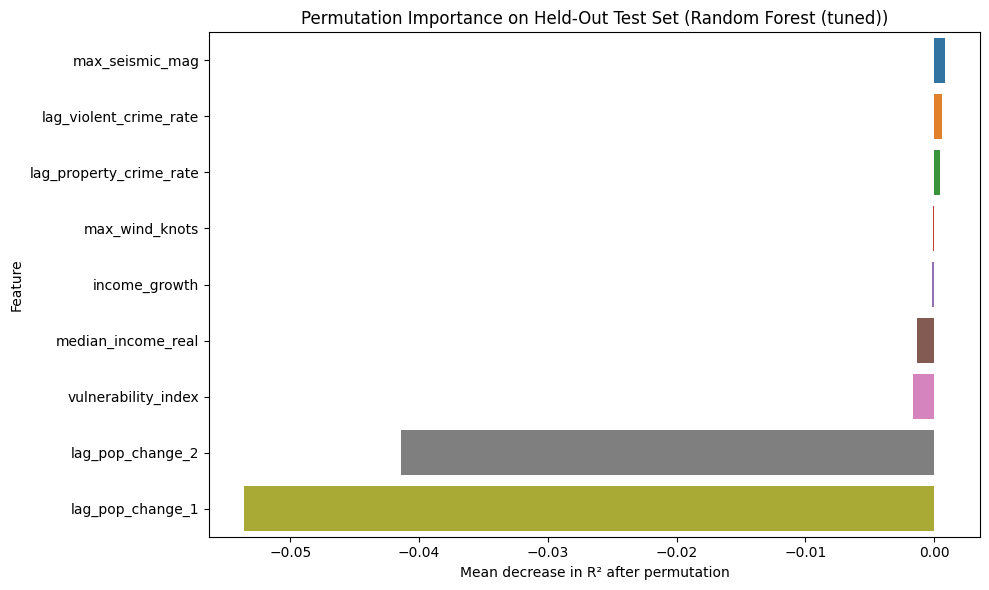

In [7]:
perm_result = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42,
    scoring='r2',
    n_jobs=-1
)

feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance_Mean': perm_result.importances_mean,
    'Importance_SD': perm_result.importances_std
}).sort_values(by='Importance_Mean', ascending=False)

display(feature_importance_df)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance_df,
    x='Importance_Mean',
    y='Feature',
    hue='Feature',
    dodge=False,
    legend=False
)
plt.title(f'Permutation Importance on Held-Out Test Set ({best_model_name})')
plt.xlabel('Mean decrease in R² after permutation')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


### Interpretation: Permutation Importance

The chart above ranks predictors by how much held-out performance deteriorates when each variable is randomly permuted. Because the selected Phase 2 model may now be either **Random Forest** or **HistGradientBoosting**, the rankings should be interpreted as model-based signals rather than causal effects.

In particular, the newly added **lagged population change** and **income growth** features help reveal whether recent demographic momentum is more informative than static socioeconomic levels alone.


## 5. Prediction Distribution: Actual vs. Predicted

This scatter plot compares the **selected best model's** predictions with observed population change in the held-out future period.


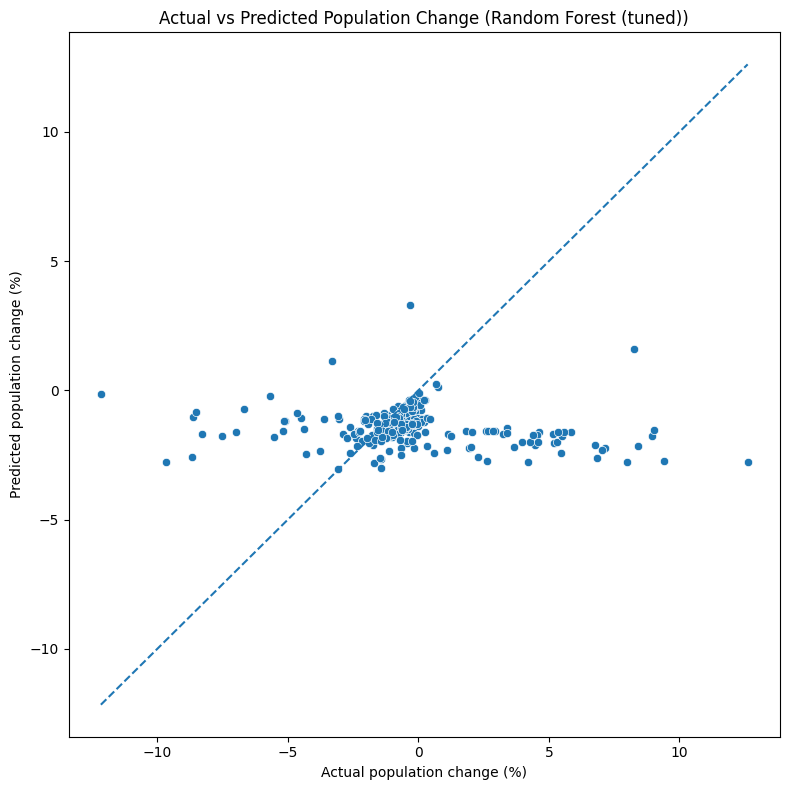

In [8]:
results_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_best_pred
})

plt.figure(figsize=(8, 8))
sns.scatterplot(data=results_df, x='Actual', y='Predicted')
plt.plot(
    [results_df['Actual'].min(), results_df['Actual'].max()],
    [results_df['Actual'].min(), results_df['Actual'].max()],
    linestyle='--'
)
plt.title(f'Actual vs Predicted Population Change ({best_model_name})')
plt.xlabel('Actual population change (%)')
plt.ylabel('Predicted population change (%)')
plt.tight_layout()
plt.show()


### Interpretation: Actual vs. Predicted Distribution

This figure is a visual audit of model behavior on unseen future data. Points closer to the diagonal indicate more accurate forecasts. Because the selected best model may now be a **boosting model** rather than a Random Forest, this plot is the most direct phase-level visual summary of generalization performance.


In [9]:
data_output_path = Path('../data/processed_puerto_rico_data.csv')
df_model.to_csv(data_output_path, index=False)

analysis_dir = Path('../analysis')
analysis_dir.mkdir(parents=True, exist_ok=True)

model_summary = {
    'best_model_name': best_model_name,
    'phase1_baseline_r2': float(phase1_baseline_r2),
    'rf_best_params': rf_grid_search.best_params_,
    'hgb_best_params': lgbm_grid_search.best_params_,
    'lgbm_best_params': lgbm_grid_search.best_params_,  # backward compatibility
    'comparison_table': comparison_df.to_dict(orient='records')
}

with open(analysis_dir / 'phase2_model_selection_summary.json', 'w') as f:
    json.dump(model_summary, f, indent=4)

print(f"Processed modeling dataset saved to: {data_output_path}")
print(f"Model selection summary saved to: {analysis_dir / 'phase2_model_selection_summary.json'}")


Processed modeling dataset saved to: ../data/processed_puerto_rico_data.csv
Model selection summary saved to: ../analysis/phase2_model_selection_summary.json


## Phase 2 Conclusion

Phase 2 extended the baseline analysis by fitting flexible nonlinear models on the same SVI-enhanced, time-aware feature pipeline.

### What changed in this update
- Added **lagged population change** (`lag_pop_change_1`, `lag_pop_change_2`)
- Added **income growth**
- Compared **Random Forest** against **HistGradientBoosting**
- Selected the strongest tuned model for downstream forecasting and scenario analysis

### Interpretation
If performance improves meaningfully over Phase 1, that suggests Puerto Rico population change contains nonlinear structure and short-run momentum that a simple linear baseline fails to capture. If performance remains weak, the conclusion is still informative: municipal population change is difficult to forecast with the currently available feature set, even after adding autoregressive and boosting-based structure.
